# Análise Exploratória de Dados

### Importações e Configurações

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.decomposition import PCA
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Leitura dos Dados

| Variable Name | Role    | Type       | Description              | Units | Missing Values |
|---------------|---------|------------|---------------------------|-------|----------------|
| X1            | Feature | Continuous | Relative Compactness      |       | no             |
| X2            | Feature | Continuous | Surface Area              |       | no             |
| X3            | Feature | Continuous | Wall Area                 |       | no             |
| X4            | Feature | Continuous | Roof Area                 |       | no             |
| X5            | Feature | Continuous | Overall Height            |       | no             |
| X6            | Feature | Integer    | Orientation               |       | no             |
| X7            | Feature | Continuous | Glazing Area              |       | no             |
| X8            | Feature | Integer    | Glazing Area Distribution |       | no             |
| Y1            | Target  | Continuous | Heating Load              |       | no             |
| Y2            | Target  | Continuous | Cooling Load              |       | no             |

In [4]:
raw_data = pd.read_excel('../datasets/ENB2012_data.xlsx')

### Análise Inicial

In [6]:
raw_data.shape

(768, 10)

In [7]:
raw_data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [8]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [15]:
# Número de Valores Ausentes
raw_data.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

Nenhum valor ausente encontrado

In [9]:
# Contagem de Valores Únicos
raw_data['X6'].value_counts(dropna=False)

X6
2    192
3    192
4    192
5    192
Name: count, dtype: int64

In [10]:
# Contagem de Valores Únicos
raw_data['X8'].value_counts(dropna=False)

X8
1    144
2    144
4    144
3    144
5    144
0     48
Name: count, dtype: int64

In [14]:
# Contagem de Valores Únicos
raw_data['X7'].value_counts(dropna=False)

X7
0.10    240
0.25    240
0.40    240
0.00     48
Name: count, dtype: int64

Tamanho do dataset relativamente pequeno (768 linhas), tipos das variáveis corretas (inteiras ou float), aparente boa distribuição das variáveis inteiras Orientation, e Glazing Area Distribution. Glazing Area Distribution possui mínimo zero mas Glazing Area possuindo o mesmo número de zeros, indica que esse é um dado do problema e não uma ausência.

In [11]:
raw_data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
X1,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.8300,0.98
X2,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.1250,808.50
X3,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.0000,416.50
X4,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.5000,220.50
X5,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.0000,7.00
X6,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.2500,5.00
X7,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.4000,0.40
X8,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.0000,5.00
Y1,768.0,22.307195,10.090204,6.01,12.9925,18.95,31.6675,43.10
Y2,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


Pontos a serem considerados com atenção:

As variáveis Roof Area, Overall Height e Glazing Area podem possuir limites superiores de medição, já que o valor máximo é o mesmo do Q3;

As variáveis target possuem média maior que a mediana, o que indica certo viés na distribuição dos dados;

Escalas muito distintas entre as variáveis mean(X7)~0.23, mean(X2)~671.70;

As variáveis target tem máximos relativamente distantes do Q3, o que pode indicar presença de outliers nas variáveis dependentes;

### Plots para Análises

#### Análise de outliers com boxplot

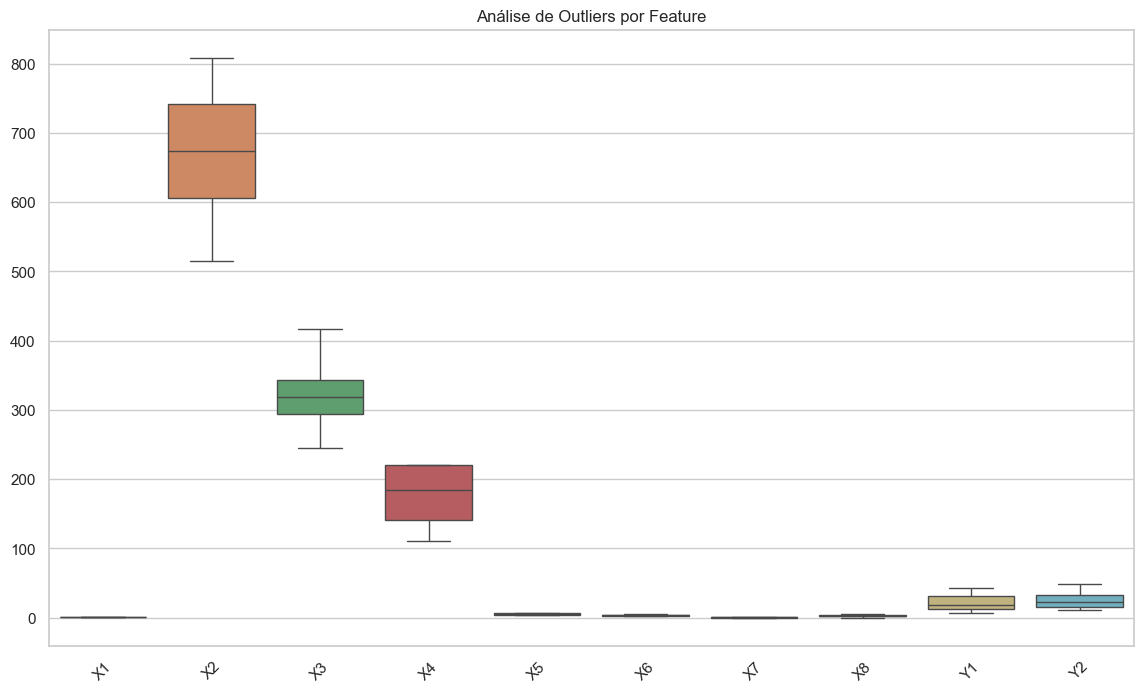

In [87]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=raw_data)
plt.title("Análise de Outliers por Feature")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Outliers com Z-score
z_scores = np.abs(stats.zscore(raw_data.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).sum(axis=0)
pd.Series(outliers, index=raw_data.select_dtypes(include=[np.number]).columns)

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

Os boxplots não mostram outliers visíveis, assim como não existem pontos no dataset com mais ou menos de 3 Z-Scores.

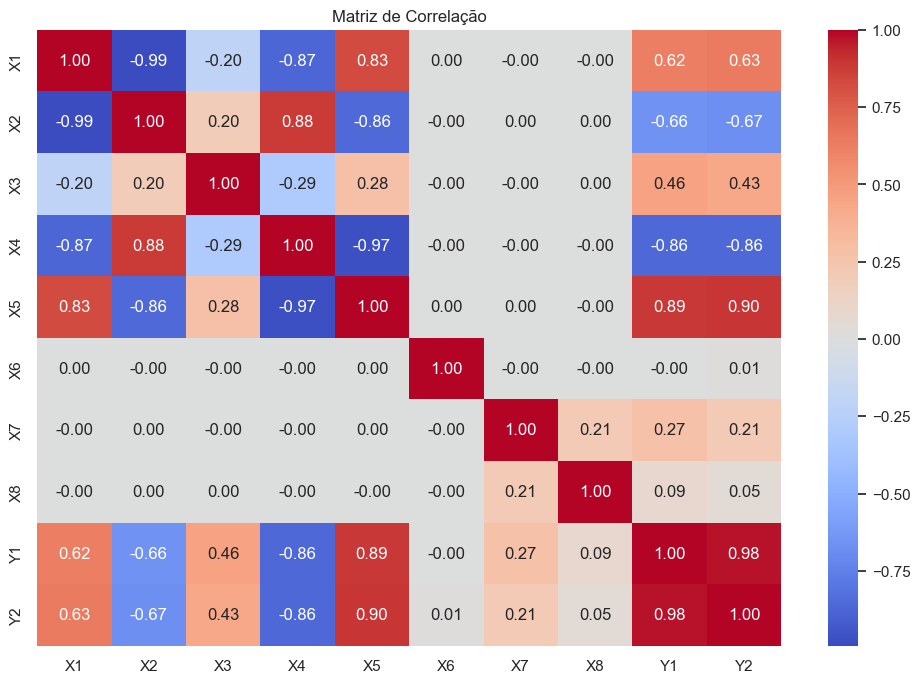

In [18]:
# Análise de correlação
plt.figure(figsize=(12, 8))
corr_matrix = raw_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

In [78]:
# Correlação com a target ordenada
y1_corr = raw_data.corr()['Y1'].drop('Y1').sort_values(key=abs, ascending=False)
y1_corr

Y2    0.975862
X5    0.889430
X4   -0.861828
X2   -0.658120
X1    0.622272
X3    0.455671
X7    0.269842
X8    0.087368
X6   -0.002587
Name: Y1, dtype: float64

In [79]:
# Correlação com a target ordenada
y2_corr = raw_data.corr()['Y2'].drop('Y2').sort_values(key=abs, ascending=False)
y2_corr

Y1    0.975862
X5    0.895785
X4   -0.862547
X2   -0.672999
X1    0.634339
X3    0.427117
X7    0.207505
X8    0.050525
X6    0.014290
Name: Y2, dtype: float64

Do plot e da análise de correlação com as variáveis targets, podemos concluir que:

X1 e X2 são extremamente correlacionadas negativamente (-0.99) o que pode ser redundante para o modelo;

X4 com X2, X5, possuem relação forte, o que é esperado já que se tratam de área do telhado, superfície e altura total;

X5 com as targets Y1 e Y2, relação muito forte r=~0.89, indica que a Altura geral é um ótimo preditor para Y1 e Y2;

Y1 e Y2 são altamente correlacionados r=0.98, provavelmente relacionada a um mesmo fenomeno físico ou semalhante;

X1 com as targets Y1 e Y2 possuem relação moderada, r=~0.62;

X1 com as targets Y1 e Y2 possuem relação moderada, r=~0.45;

X6, X7, X8 possuem pouca ou nenhuma relação com os targets ou demais features. Com mais testes podemos avaliar o descarte ou manutenção.

Y1 e Y2 tem uma correlação de 0.98, assim podemos priorizar um modelo multi-output para predição.


Possíveis problemas:

Variáveis como X1, X2, X4 e X5 estão altamente correlacionadas entre si, o que indica multicolinearidade;


### Distribuição das Targets

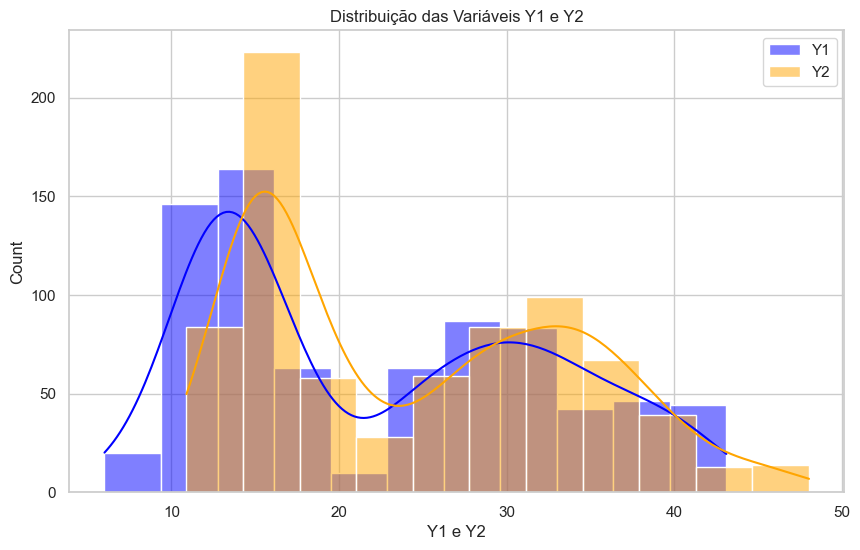

In [60]:
# Distribuição da variável target
plt.figure(figsize=(10, 6))
sns.histplot(raw_data['Y1'], kde=True, label='Y1', color='blue')
sns.histplot(raw_data['Y2'], kde=True, label='Y2', color='orange')
plt.xlabel("Y1 e Y2")
plt.title("Distribuição das Variáveis Y1 e Y2")
plt.legend()
plt.show()

Pelas distribuições das variáveis target, vemos que nenhuma delas possui características de uma distribuição gaussiana;

Em vez disso, parecem possuir uma distribuição bimodal. Ambas as variáveis apresentam dois picos principais de valores. O primeiro entre 10~20 e o segundo entre 30~40;

O comportamento pode indicar que no dataset existem dois tipos diferentes de construções;

Y1 tem uma distribuição levemente assimétrica à direita, com o segundo pico em torno de 30.

Y2 é mais simétrica que Y1, mas também mostra cauda à direita.

Mesmo com distribuições um pouco diferentes, ambas têm formatos parecidos, o que era esperado pela extrema correlação de 0.98. Essa alta correlação pode indicar que os modelos para as duas variáveis podem ser muito próximos;

Como as distribuições não possuem uma distribuição normal padrão, alguns algoritmos que esperam curvas dessa forma podem ser impactados;

#### Análise de distribuição das features

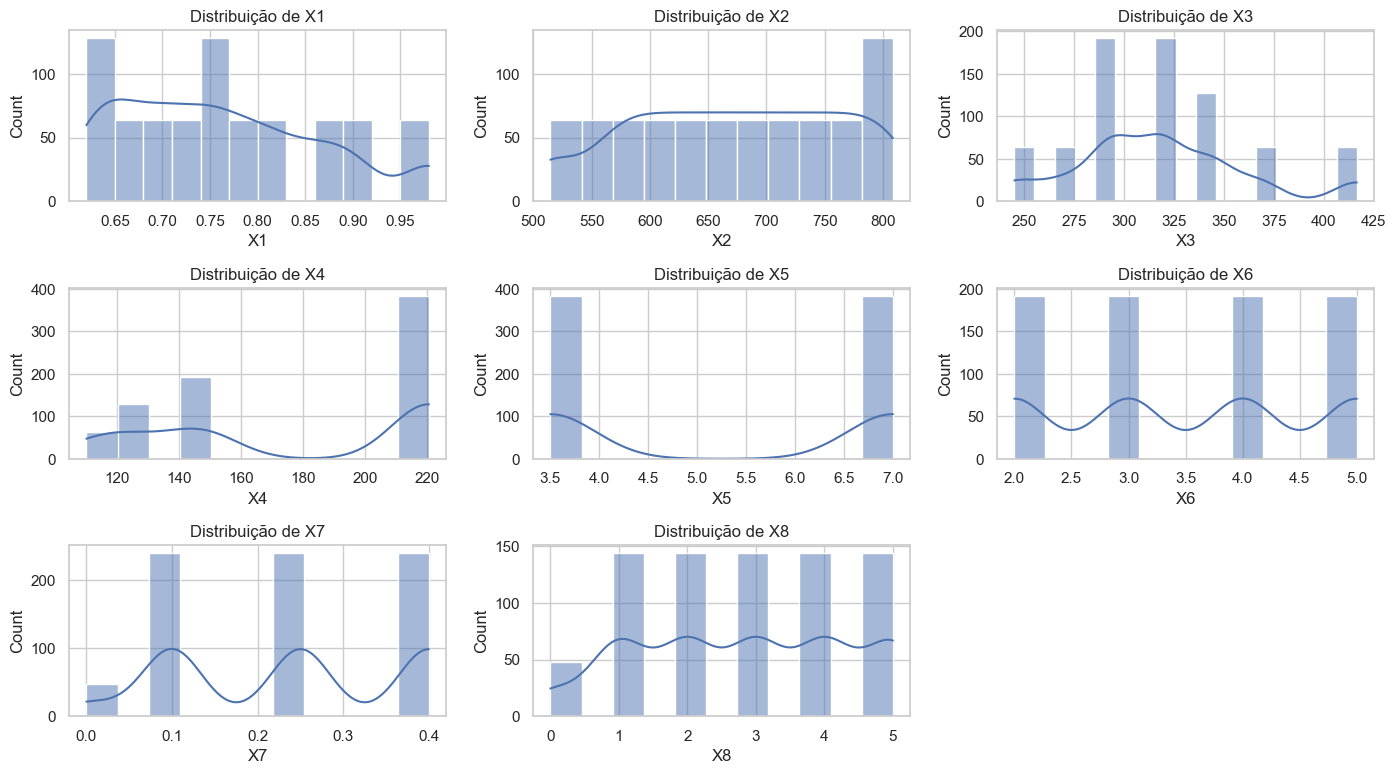

In [ ]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(raw_data.columns[:-2]):
    plt.subplot(4, 3, i+1)
    sns.histplot(raw_data[col], kde=True)
    plt.title(f"Distribuição de {col}")
plt.tight_layout()
plt.show()

Dos plots de distribuição das features podemos ver que:

X5 (Overall Height) possui dois picos bem definidos, ou seja, pode representar dois tipos distintos de construções, ainda mais, pela alta correlação da variável com as targets, r=~0.90 pode ser uma pista para explicar o comportamento bimodal das duas variáveis. (Um dos possíveis tratamentos pode ser o treinamento de dois modelos).

X4 (Roof Area) também possui dois picos não tão bem definidos, mas da mesma maneira pode influenciar o comportamento bimodal das targets, devido a alta correlação inversa r=~-0.89.

#### Verificação de multicolinearidade com VIF

In [106]:
X_features = raw_data.drop(columns=['Y1', 'Y2'])
vif_data = pd.DataFrame()
vif_data["feature"] = X_features.columns
vif_data["VIF"] = [variance_inflation_factor(X_features.values, i) for i in range(X_features.shape[1])]
vif_data

c:\Users\rikar\anaconda3\envs\case-env\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,X1,168.948751
1,X2,inf
2,X3,inf
3,X4,inf
4,X5,134.035782
5,X6,10.796725
6,X7,4.293656
7,X8,4.496320


O teste de Variance Inflation Factor (idealmente VIF < 5) confirma que existe grande multicolinearidade entre os dados. O que pode ser melhor identificado olhando o heatmap anterior. Assim, para o treinamento do modelo pode se fazer necessário o tratamento dessas variáveis, seja removendo diretamente, seja com PCA ou outras técnicas.

#### Escalonamento para Feature Importance

In [103]:
# Preparação dos dados para treino
X = raw_data.drop(['Y1', 'Y2'], axis=1)
y = raw_data[['Y1', 'Y2']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalonamento de features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n=== Dados preparados ===")
print(f"Dimensões dos dados de treino: {X_train_scaled.shape}")
print(f"Dimensões dos dados de teste: {X_test_scaled.shape}")


=== Dados preparados ===
Dimensões dos dados de treino: (614, 8)
Dimensões dos dados de teste: (154, 8)


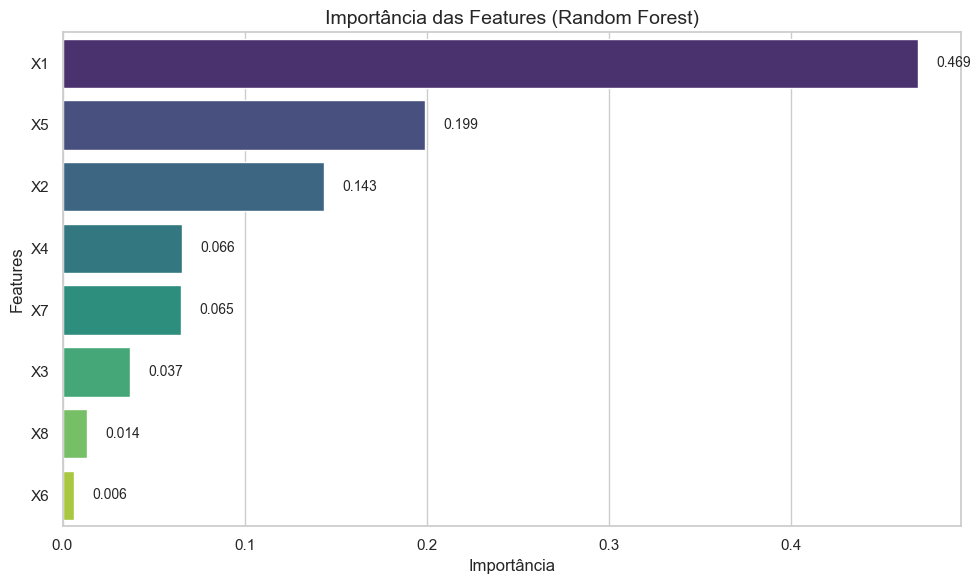

In [108]:
# Treinamento do modelo Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Cálculo da importância das features
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Criação do gráfico
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=importances, y=importances.index, hue=importances.index, palette="viridis", legend=False)

# Adicionando os valores nas barras
for bar in bars.patches:
    # Obtém a largura da barra (valor da importância)
    width = bar.get_width()
    # Obtém a posição vertical da barra
    y = bar.get_y() + bar.get_height() / 2
    # Adiciona o texto ao lado da barra
    plt.text(width + 0.01, y, f"{width:.3f}", va="center", fontsize=10)

# Título e exibição do gráfico
plt.title("Importância das Features (Random Forest)", fontsize=14)
plt.xlabel("Importância", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

Considerando as análises de correlação e o feature importance para o RandomForest, 

| Feature | Importância | Comentário |
|---------|-------------|------------|
| **X1**  | **0.469**    | Maior relevancia, altamente colinear com X2,X4,X5. |
| **X5**  | **0.199**    | Importante e com pouca colinearidade. - Manter |
| **X2**  | **0.143**    | Importante, colinear com X1, X3, X4. |
| **X4**  | 0.066        | Menor importância e colinear com X1, X2, X5 — candidato à remoção. |
| **X7**  | 0.065        | Pequena importância, baixa colinearidade — Manter. |
| **X3**  | 0.037        | Menor importancia e baixa colinearidade — candidato à remoção. |
| **X8**  | 0.014        | Irrelevante e sem correlação com targets — Remover. |
| **X6**  | 0.006        | Irrelevante e sem correlação com targets — Remover. |


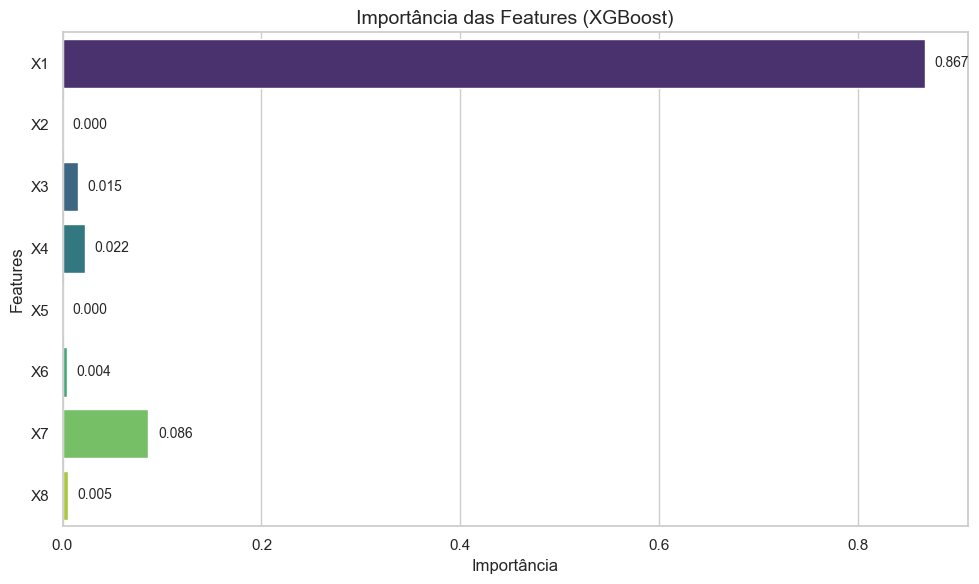

In [145]:
# Treinamento do modelo XGBoost (modelo de regressão de saída dupla)
model = xgb.XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Cálculo da importância das features
importances = model.feature_importances_

# Criação do gráfico
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=importances, y=X_train.columns, hue=X_train.columns, palette="viridis", legend=False)

# Adicionando os valores nas barras
for bar in bars.patches:
    width = bar.get_width()  # Valor da importância
    y = bar.get_y() + bar.get_height() / 2  # Posição vertical
    plt.text(width + 0.01, y, f"{width:.3f}", va="center", fontsize=10)

# Título e exibição do gráfico
plt.title("Importância das Features (XGBoost)", fontsize=14)
plt.xlabel("Importância", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()


Considerando as análises de correlação e o feature importance para o XGBoost, 

| Feature | Importância | Comentário |
|---------|-------------|------------|
| **X1**  | **0.867**    | Principal feature, altamente colinear com X2,X4,X5. |
| **X7**  | **0.086**        | Pequena importância, baixa colinearidade — Manter. |
| **X4**  | **0.022**        | Menor importância e colinear — candidato à remoção. |
| **X3**  | 0.015        | Menos importante e baixa colinearidade — candidato à remoção. |
| **X8**  | 0.005        | Irrelevante e sem correlação com targets — Remover. |
| **X6**  | 0.004        | Irrelevante e sem correlação com targets — Remover. |
| **X5**  | 0.000    | Irrelevante mas com alta correlação com targets — candidato à remoção. |
| **X2**  | 0.000    | Irrelevante e com correlação média com targets — candidato à remoção. |






### As tabelas de Feature Importance mostram possíveis tratamentos para as variáveis específicas, seja por suas correlações com outras variáveis, seja por suas importâncias nos dois modelos considerados. A partir daqui, podemos seguir para o próximo passo, que é o treinamento e teste dos modelos. Caso os resultados sejam ruins, novas técnicas de tratamento podem precisar ser testadas. Primeiramente, testaremos modelos com duas saídas, Y1 e Y2, o que é motivado pela alta correlação (r = 0,98) das variáveis target. Avaliaremos os casos de treinamento completo, remoção de variáveis ou uso de PCA. Com base nos resultados das métricas obtidas nesse teste, caso necessário, poderemos avaliar o treinamento dessas variáveis separadamente ou explorar outras técnicas.